Distribution Shift Evaluation (Cityscapes)
This notebook evaluates a trained Cityscapes segmentation baseline under synthetic corruptions (blur, noise, brightness) to quantify robustness.

1) Setup

In [1]:
from pathlib import Path
import sys
import torch

# Notebook lives in notebooks/, so parent is the project root.
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

DATA = ROOT / "data"
OUT = ROOT / "outputs"
WEIGHTS = ROOT / "weights"
OUT.mkdir(exist_ok=True)

# Prefer GPU when available.
device = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT:", ROOT)
print("DATA:", DATA)
print("WEIGHTS:", WEIGHTS)
print("device:", device)

ROOT: c:\Users\dhruv\temporal_cityscapes
DATA: c:\Users\dhruv\temporal_cityscapes\data
WEIGHTS: c:\Users\dhruv\temporal_cityscapes\weights
device: cuda


2) Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF

from src.dataset_cityscapes import CityscapesTrainId
from src.train_utils import get_device, make_deeplab, evaluate, load_checkpoint

Load validation dataset

In [3]:
SIZE_HW = (512, 1024)

val_clean = CityscapesTrainId(DATA, split="val", size_hw=SIZE_HW)

def make_loader(ds, bs=6, shuffle=False):
    # Multi-worker loader is fine for the clean dataset and speeds up eval.
    return DataLoader(
        ds, batch_size=bs, shuffle=shuffle,
        num_workers=8, pin_memory=True, persistent_workers=True,
        drop_last=False
    )

loader_val_clean = make_loader(val_clean, bs=6, shuffle=False)
len(val_clean)

500

Define corruption wrapper

In [4]:
class CorruptWrapper(torch.utils.data.Dataset):
    def __init__(self, base_ds, mode: str):
        self.base = base_ds
        self.mode = mode

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y, meta = self.base[idx]

        # Corrupt image only; keep labels untouched.
        if self.mode == "blur":
            x = TF.gaussian_blur(x, kernel_size=7, sigma=1.35)
        elif self.mode == "noise":
            x = x + 0.14 * torch.randn_like(x)
            x = torch.clamp(x, -3.0, 3.0)
        elif self.mode == "bright":
            x = x * 1.25
            x = torch.clamp(x, -3.0, 3.0)
        else:
            raise ValueError(f"Unknown corruption mode: {self.mode}")

        meta = dict(meta)
        meta["corruption"] = self.mode
        return x, y, meta

Load trained model checkpoint

In [5]:
device = get_device()

ckpt_path = WEIGHTS / "deeplabv3_cityscapes_baseline.pt"
model = make_deeplab(num_classes=19, pretrained=True).to(device)

ckpt = load_checkpoint(ckpt_path, model, map_location=device)
trained_size_hw = ckpt.get("size_hw", (512, 1024))
print("Loaded:", ckpt_path)
print("Checkpoint keys:", list(ckpt.keys()))
print("Trained size_hw:", trained_size_hw)

Loaded: c:\Users\dhruv\temporal_cityscapes\weights\deeplabv3_cityscapes_baseline.pt
Checkpoint keys: ['model', 'size_hw']
Trained size_hw: (512, 1024)


In [6]:
from torch.utils.data import DataLoader

# Safety fallback when cells are run out of order.
if "device" not in globals():
    device = get_device() if "get_device" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")

if "trained_size_hw" not in globals():
    trained_size_hw = SIZE_HW if "SIZE_HW" in globals() else (512, 1024)

if "CorruptWrapper" not in globals():
    raise NameError("CorruptWrapper is not defined. Run the corruption-wrapper cell first.")

BATCH_SIZE = 4
PIN_MEMORY = (device.type == "cuda") if hasattr(device, "type") else (str(device) == "cuda")

NUM_WORKERS_CLEAN = 4
NUM_WORKERS_CORRUPT = 0

# Match evaluation resolution to training when checkpoint metadata exists.
SIZE_HW = trained_size_hw
val_clean = CityscapesTrainId(DATA, split="val", size_hw=SIZE_HW)

val_blur = CorruptWrapper(val_clean, mode="blur")
val_noise = CorruptWrapper(val_clean, mode="noise")
val_bright = CorruptWrapper(val_clean, mode="bright")

loader_val_clean = DataLoader(
    val_clean,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS_CLEAN,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS_CLEAN > 0),
)
loader_val_blur = DataLoader(
    val_blur,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS_CORRUPT,
    pin_memory=PIN_MEMORY,
)
loader_val_noise = DataLoader(
    val_noise,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS_CORRUPT,
    pin_memory=PIN_MEMORY,
)
loader_val_bright = DataLoader(
    val_bright,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS_CORRUPT,
    pin_memory=PIN_MEMORY,
)

print("Loaders ready:", len(loader_val_clean), len(loader_val_blur), len(loader_val_noise), len(loader_val_bright))
print("workers clean/corrupt:", NUM_WORKERS_CLEAN, NUM_WORKERS_CORRUPT)

Loaders ready: 125 125 125 125
workers clean/corrupt: 4 0


Evaluate mIoU across conditions

In [7]:
import time
import torch

print("torch.cuda.is_available():", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("device variable:", device)
print("model parameter device:", next(model.parameters()).device)

x, y, _ = next(iter(loader_val_clean))
print("batch (before to):", x.device, y.device, x.shape)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

t0 = time.time()
x = x.to(device, non_blocking=True)
with torch.inference_mode():
    out = model(x)["out"]
if torch.cuda.is_available():
    torch.cuda.synchronize()
t1 = time.time()

print("batch (after to):", x.device)
print("output device:", out.device, "shape:", tuple(out.shape))
print(f"one forward pass time: {t1 - t0:.3f}s")
if torch.cuda.is_available():
    print(f"cuda mem allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"cuda peak allocated: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

torch.cuda.is_available(): True
GPU: NVIDIA GeForce RTX 5070
device variable: cuda
model parameter device: cuda:0
batch (before to): cpu cpu torch.Size([4, 3, 512, 1024])
batch (after to): cuda:0
output device: cuda:0 shape: (4, 19, 512, 1024)
one forward pass time: 1.108s
cuda mem allocated: 0.53 GB
cuda peak allocated: 1.31 GB


In [8]:
import time
import importlib
import src.train_utils as train_utils

# Pull latest evaluate() implementation from src while iterating in notebooks.
importlib.reload(train_utils)
evaluate = train_utils.evaluate

USE_AMP_EVAL = True
PROGRESS_EVERY = 1

print("Evaluation mode: full validation set")

results = {}
t0 = time.time()

for name, loader in [
    ("clean", loader_val_clean),
    ("blur", loader_val_blur),
    ("noise", loader_val_noise),
    ("bright", loader_val_bright),
]:
    t_cond = time.time()
    print(f"\nStarting {name}...")
    miou, _ = evaluate(
        model, loader, num_classes=19, device=device,
        use_amp=USE_AMP_EVAL, max_batches=None,
        progress=True, progress_every=PROGRESS_EVERY, progress_prefix=name,
    )
    results[name] = miou
    print(f"{name:>7s}: {miou:.4f}  ({time.time() - t_cond:.1f}s)")

elapsed = time.time() - t0
print(f"Total evaluation time: {elapsed/60:.2f} min")
results

Evaluation mode: full validation set

Starting clean...
[clean] 1/125 (  0.8%) | elapsed 0.8s | eta 102.9s
[clean] 2/125 (  1.6%) | elapsed 0.9s | eta 57.3s
[clean] 3/125 (  2.4%) | elapsed 1.0s | eta 42.5s
[clean] 4/125 (  3.2%) | elapsed 1.2s | eta 35.0s
[clean] 5/125 (  4.0%) | elapsed 1.3s | eta 30.2s
[clean] 6/125 (  4.8%) | elapsed 1.4s | eta 26.9s
[clean] 7/125 (  5.6%) | elapsed 1.5s | eta 24.6s
[clean] 8/125 (  6.4%) | elapsed 1.6s | eta 23.0s
[clean] 9/125 (  7.2%) | elapsed 1.7s | eta 21.6s
[clean] 10/125 (  8.0%) | elapsed 1.8s | eta 20.3s
[clean] 11/125 (  8.8%) | elapsed 1.9s | eta 19.3s
[clean] 12/125 (  9.6%) | elapsed 2.0s | eta 18.4s
[clean] 13/125 ( 10.4%) | elapsed 2.1s | eta 18.2s
[clean] 14/125 ( 11.2%) | elapsed 2.2s | eta 17.5s
[clean] 15/125 ( 12.0%) | elapsed 2.3s | eta 17.0s
[clean] 16/125 ( 12.8%) | elapsed 2.4s | eta 16.5s
[clean] 17/125 ( 13.6%) | elapsed 2.6s | eta 16.2s
[clean] 18/125 ( 14.4%) | elapsed 2.7s | eta 15.9s
[clean] 19/125 ( 15.2%) | elapsed 

{'clean': 0.6482956409454346,
 'blur': 0.5285175442695618,
 'noise': 0.31972113251686096,
 'bright': 0.583081066608429}

Print a clean results table

In [9]:
print("mIoU results (val):")
for k in ["clean", "blur", "noise", "bright"]:
    print(f"{k:>7s}: {results[k]:.4f}")

with open(OUT / "shift_eval_results.txt", "w") as f:
    for k in ["clean", "blur", "noise", "bright"]:
        f.write(f"{k}: {results[k]:.6f}\n")
print("Saved:", OUT / "shift_eval_results.txt")

mIoU results (val):
  clean: 0.6483
   blur: 0.5285
  noise: 0.3197
 bright: 0.5831
Saved: c:\Users\dhruv\temporal_cityscapes\outputs\shift_eval_results.txt


Qualitative visualization utilities

In [10]:
@torch.no_grad()
def predict_one(model, x):
    model.eval()
    x = x.unsqueeze(0).to(device)
    logits = model(x)["out"]
    pred = logits.argmax(dim=1).squeeze(0).cpu()
    return pred

def denorm_img(x):
    # Undo ImageNet normalization for display.
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = x.cpu() * std + mean
    return torch.clamp(img, 0, 1)

Show side-by-side for a few examples

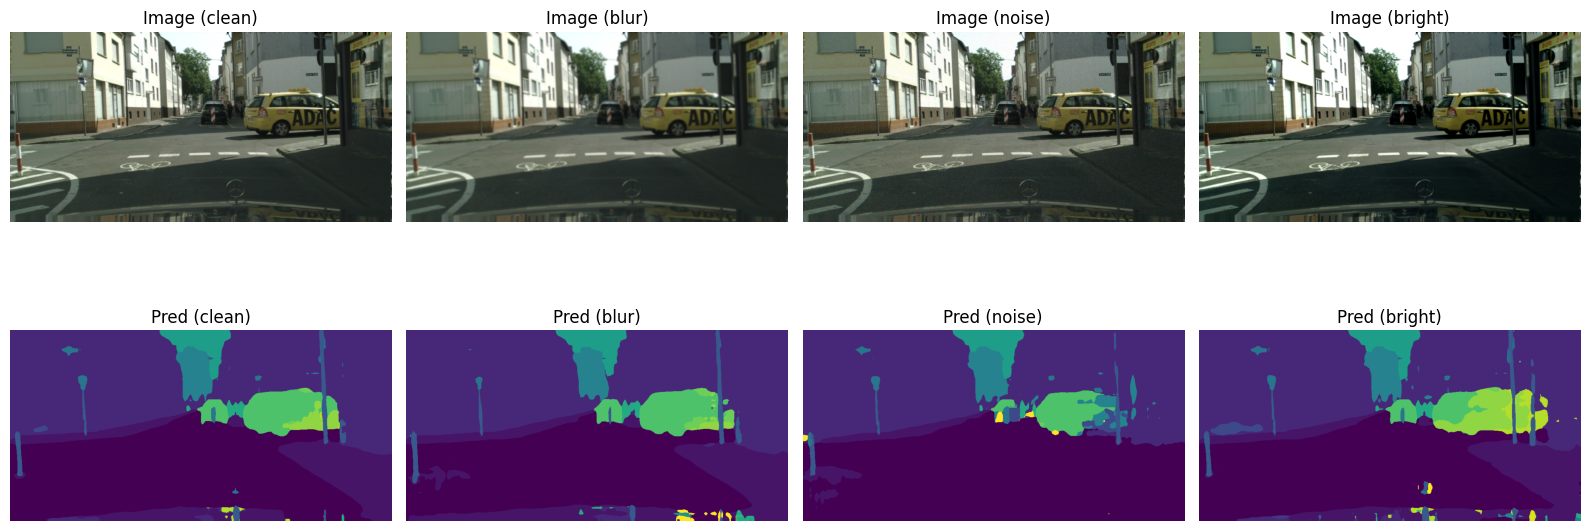

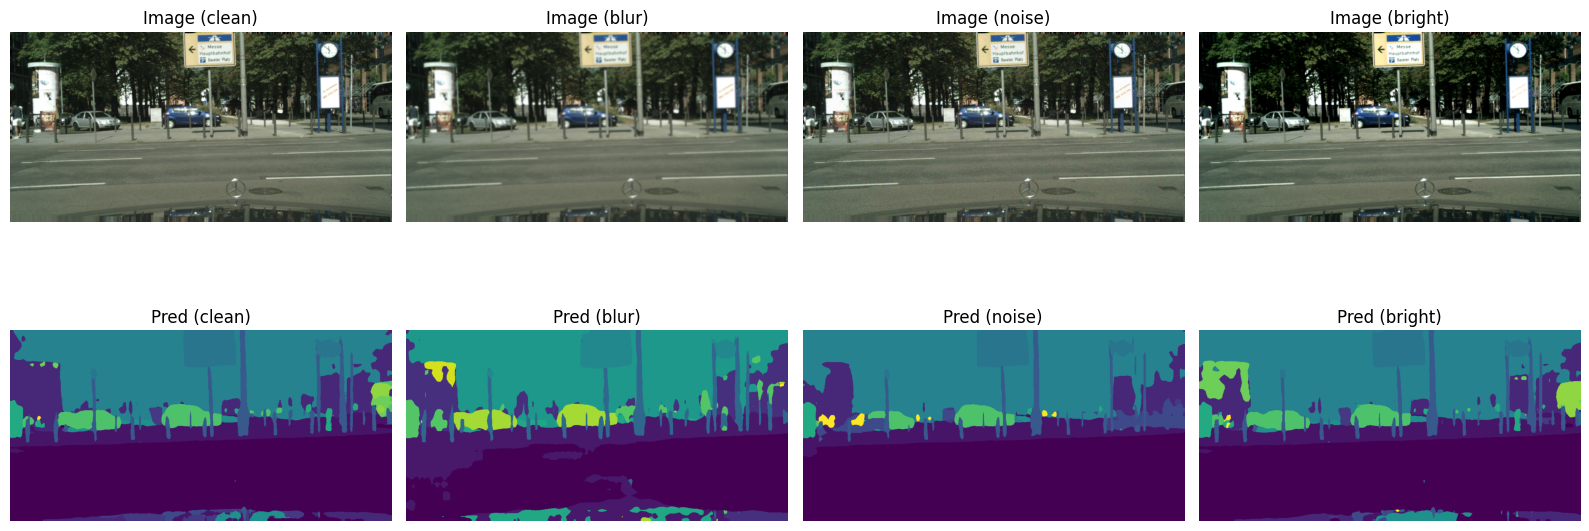

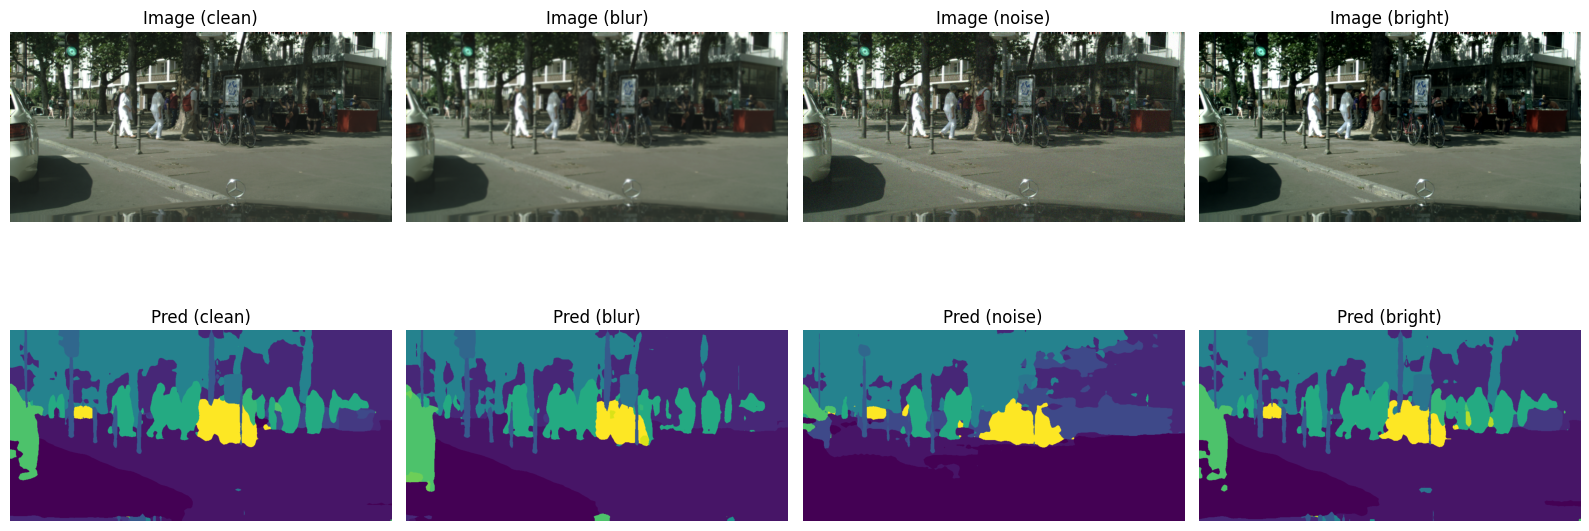

In [11]:
def show_example(idx=0):
    x_clean, y, _ = val_clean[idx]

    x_blur, _, _ = val_blur[idx]
    x_noise, _, _ = val_noise[idx]
    x_bright, _, _ = val_bright[idx]

    p_clean = predict_one(model, x_clean)
    p_blur = predict_one(model, x_blur)
    p_noise = predict_one(model, x_noise)
    p_bright = predict_one(model, x_bright)

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))

    # Top row: inputs under each condition. Bottom row: model predictions.
    axes[0, 0].imshow(denorm_img(x_clean).permute(1, 2, 0)); axes[0, 0].set_title("Image (clean)")
    axes[0, 1].imshow(denorm_img(x_blur).permute(1, 2, 0)); axes[0, 1].set_title("Image (blur)")
    axes[0, 2].imshow(denorm_img(x_noise).permute(1, 2, 0)); axes[0, 2].set_title("Image (noise)")
    axes[0, 3].imshow(denorm_img(x_bright).permute(1, 2, 0)); axes[0, 3].set_title("Image (bright)")

    axes[1, 0].imshow(p_clean); axes[1, 0].set_title("Pred (clean)")
    axes[1, 1].imshow(p_blur); axes[1, 1].set_title("Pred (blur)")
    axes[1, 2].imshow(p_noise); axes[1, 2].set_title("Pred (noise)")
    axes[1, 3].imshow(p_bright); axes[1, 3].set_title("Pred (bright)")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_example(0)
show_example(25)
show_example(100)

Save a figure for your report

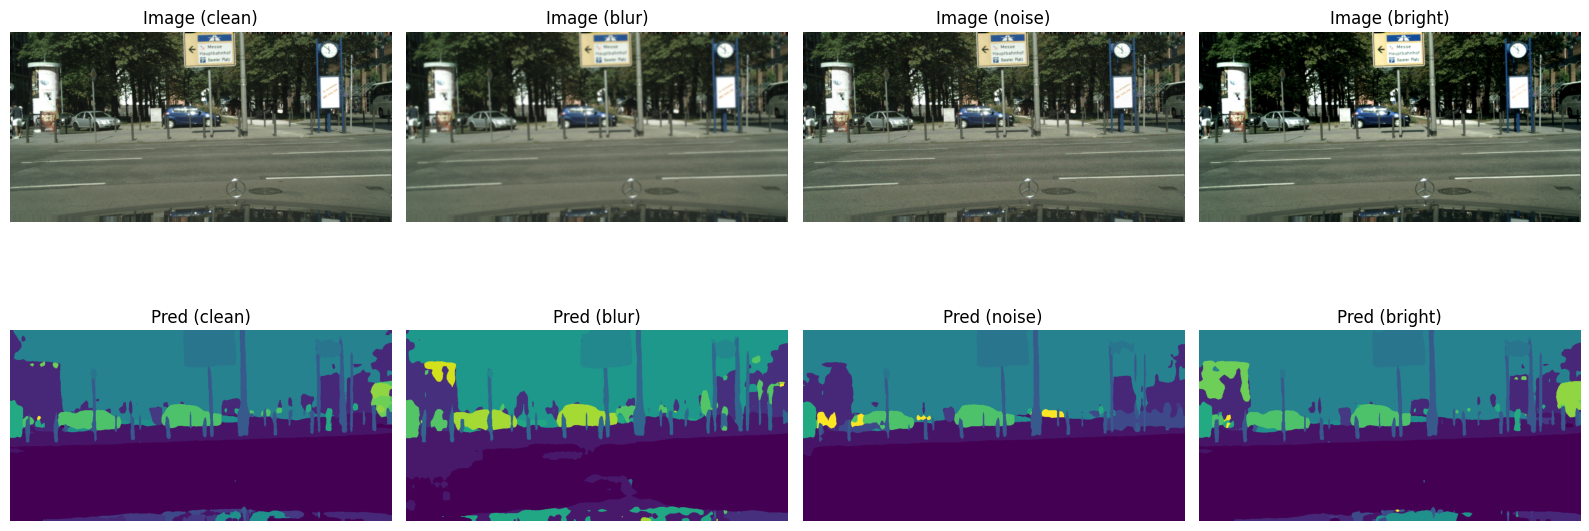

Saved: c:\Users\dhruv\temporal_cityscapes\outputs\qual_shift_example.png


In [12]:
# Save one representative qualitative panel for the report.
idx = 25
x_clean, y, _ = val_clean[idx]
x_blur, _, _ = val_blur[idx]
x_noise, _, _ = val_noise[idx]
x_bright, _, _ = val_bright[idx]

p_clean = predict_one(model, x_clean)
p_blur = predict_one(model, x_blur)
p_noise = predict_one(model, x_noise)
p_bright = predict_one(model, x_bright)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes[0, 0].imshow(denorm_img(x_clean).permute(1, 2, 0)); axes[0, 0].set_title("Image (clean)")
axes[0, 1].imshow(denorm_img(x_blur).permute(1, 2, 0)); axes[0, 1].set_title("Image (blur)")
axes[0, 2].imshow(denorm_img(x_noise).permute(1, 2, 0)); axes[0, 2].set_title("Image (noise)")
axes[0, 3].imshow(denorm_img(x_bright).permute(1, 2, 0)); axes[0, 3].set_title("Image (bright)")
axes[1, 0].imshow(p_clean); axes[1, 0].set_title("Pred (clean)")
axes[1, 1].imshow(p_blur); axes[1, 1].set_title("Pred (blur)")
axes[1, 2].imshow(p_noise); axes[1, 2].set_title("Pred (noise)")
axes[1, 3].imshow(p_bright); axes[1, 3].set_title("Pred (bright)")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()

save_path = OUT / "qual_shift_example.png"
plt.savefig(save_path, dpi=200)
plt.show()
print("Saved:", save_path)